# APS-2 Regressão

## - Guilherme Guedes
## - Luigi Sibinelli

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor # pode dar erro de 32 -> 64 bits!
                                 # instalar "brew install libomp"
                                 # (só pra MAC isso ludão)

from sklearn.model_selection import cross_val_score, RepeatedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Carregamento e Pré-processamento

### 1.1 Carregamento dos dados

Carregar o dataset Adult Census Income via `ucimlrepo`.

In [26]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 

In [27]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 1.2 Inspeção inicial

Verificar o `shape`, `tipos de dados`, `primeiras linhas` e `valores ausentes`.

" copiar " do Projeto 1 esse começo msm

In [28]:
# shape
df.shape

(48842, 15)

In [29]:
# tratando a coluna do target para remover inconsistência
df["income"] = df["income"].replace({"<=50K.": "<=50K", ">50K.": ">50K"})

#EXPLICITANDO A QT DE INSTÂNCIAS
income_counts = df["income"].value_counts()
print(income_counts)
print(f"\nSoma total: {income_counts.sum()}")

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Soma total: 48842


In [30]:
# tipos de dados
df.dtypes.astype(str).sort_values()

age                int64
fnlwgt             int64
education-num      int64
capital-gain       int64
capital-loss       int64
hours-per-week     int64
workclass         object
education         object
marital-status    object
occupation        object
relationship      object
race              object
sex               object
native-country    object
income            object
dtype: object

In [31]:
# primeiras linhas
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [32]:
# valores ausentes

### Verificando e informando quantidade de valores faltantes nas features (considerando '?' e NaN)
## OBS: valor absoluto e porcentual 

features_df = df.drop(columns=["income"]).copy()

is_question_mark = features_df.apply(
    lambda col: col.astype(str).str.strip().eq("?") if col.dtype == "object" else pd.Series(False, index=col.index)
)
is_nan = features_df.isna()

missing_mask = is_question_mark | is_nan
missing_counts = missing_mask.sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if missing_counts.empty:
    print("Nenhuma feature com valores faltantes ('?' ou NaN).")
else:
    missing_summary = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_pct": (missing_counts / len(features_df) * 100).round(2)
    })
    display(missing_summary)

,missing_count,missing_pct
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


### 1.3 Definição de X e y
Como o objetivo é prever `hours-per-week`, separamos essa coluna como target `y` e removemos ela de `X`.

In [33]:
X = df.drop('hours-per-week', axis=1).copy()
y = df['hours-per-week'].copy() #target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [34]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

### 1.4 Pipeline de pré-processamento

Definir um `ColumnTransformer` com dois sub-pipelines:
- **Numérico**: imputação pela mediana + `StandardScaler`
- **Categórico**: imputação pela moda + `OneHotEncoder`

In [35]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformer, num_cols),
        ('categorical', categorical_transformer, cat_cols)
    ]
)

In [37]:
# Visualização do preprocessor (provisório — será reconstruído após Feature Engineering)
preprocessor


,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 2. Feature Engineering

Criamos ao menos 4 novas features a partir das variáveis existentes para enriquecer o modelo.

As novas features são adicionadas ao `df` antes de refazer o split, garantindo que o pipeline de pré-processamento as capture corretamente.

### 2.1 Criação das novas features


In [38]:
df_fe = df.copy()

# Feature 1: capital_net — saldo líquido de capital -> (gain - loss)
df_fe['capital_net'] = df_fe['capital-gain'] - df_fe['capital-loss']

# Feature 2: work_experience_proxy — estimativa de anos de experiência no mercado
# Pressuposto: a pessoa entrou no mercado de trabalho após (education-num + 6) anos de vida
df_fe['work_experience_proxy'] = df_fe['age'] - df_fe['education-num'] - 6

# Feature 3: education_level — agrupamento ordinal de education-num em 4 faixas
# 0 = Fundamental (<=8), 1 = Médio (9-12), 2 = Superior (13-14), 3 = Pós-grad (>14)
edu_bins   = [0, 8, 12, 14, 16]
edu_labels = [0, 1, 2, 3]
df_fe['education_level'] = pd.cut(
    df_fe['education-num'], bins=edu_bins, labels=edu_labels
).astype(float)

# Feature 4: is_married — flag binária de casado(a) (estado civil mais comum e relevante)
df_fe['is_married'] = (
    df_fe['marital-status'].str.strip() == 'Married-civ-spouse'
).astype(int)

# Feature 5: age_educ_interaction — interação entre idade e escolaridade
df_fe['age_educ_interaction'] = df_fe['age'] * df_fe['education-num']

# Feature 6: capital_has_gain / capital_has_loss — flags para presença de capital
df_fe['capital_has_gain'] = (df_fe['capital-gain'] > 0).astype(int)
df_fe['capital_has_loss'] = (df_fe['capital-loss'] > 0).astype(int)

print("Novas features criadas:")
print(df_fe[['capital_net', 'work_experience_proxy', 'education_level',
             'is_married', 'age_educ_interaction',
             'capital_has_gain', 'capital_has_loss']].describe().T)


Novas features criadas:
                         count        mean          std     min    25%    50%  \
capital_net            48842.0  991.565313  7475.549906 -4356.0    0.0    0.0   
work_experience_proxy  48842.0   22.565497    13.871075    -2.0   11.0   21.0   
education_level        48842.0    1.145981     0.667496     0.0    1.0    1.0   
is_married             48842.0    0.458192     0.498254     0.0    0.0    0.0   
age_educ_interaction   48842.0  390.544081   176.393256    19.0  259.0  364.0   
capital_has_gain       48842.0    0.082613     0.275300     0.0    0.0    0.0   
capital_has_loss       48842.0    0.046722     0.211045     0.0    0.0    0.0   

                         75%      max  
capital_net              0.0  99999.0  
work_experience_proxy   31.0     82.0  
education_level          1.0      3.0  
is_married               1.0      1.0  
age_educ_interaction   495.0   1350.0  
capital_has_gain         0.0      1.0  
capital_has_loss         0.0      1.0  


### 2.2 Visualização das distribuições das novas features

Verificamos se as novas features numéricas possuem variância suficiente e distribuição razoável para auxiliar o modelo.


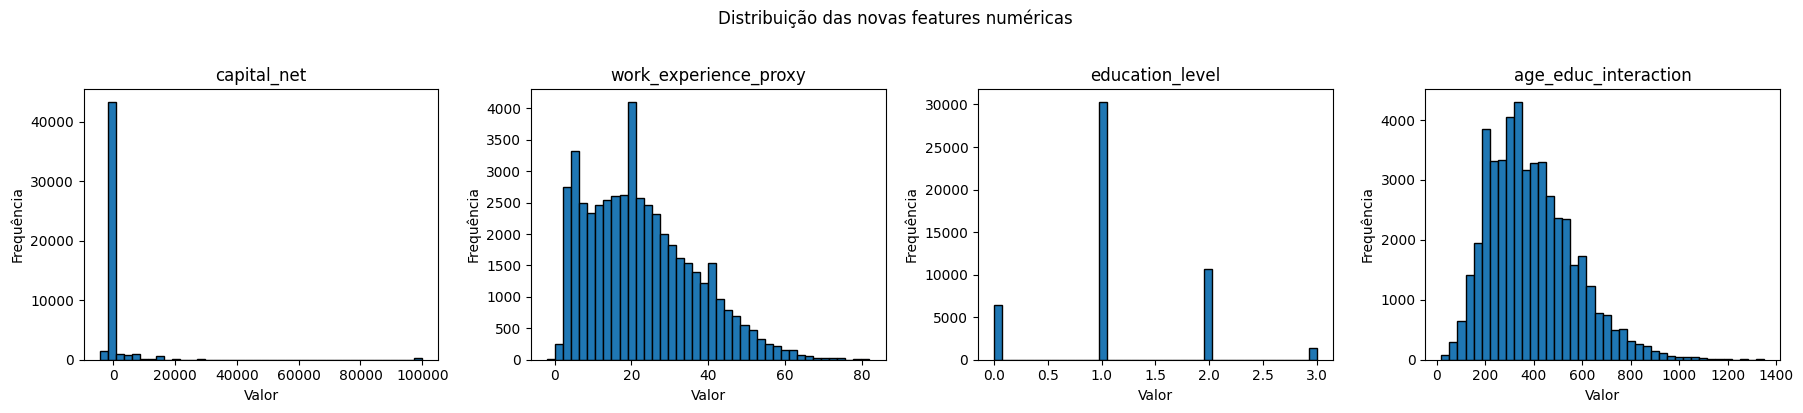

In [39]:
new_num_features = [
    'capital_net', 'work_experience_proxy',
    'education_level', 'age_educ_interaction'
]

fig, axes = plt.subplots(1, len(new_num_features), figsize=(18, 4))

for ax, col in zip(axes, new_num_features):
    ax.hist(df_fe[col].dropna(), bins=40, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das novas features numéricas', y=1.02)
plt.tight_layout()
plt.show()


### 2.3 Correlação das novas features com o target (`hours-per-week`)

Verificamos se as novas features têm correlação com o target, justificando sua inclusão no modelo.


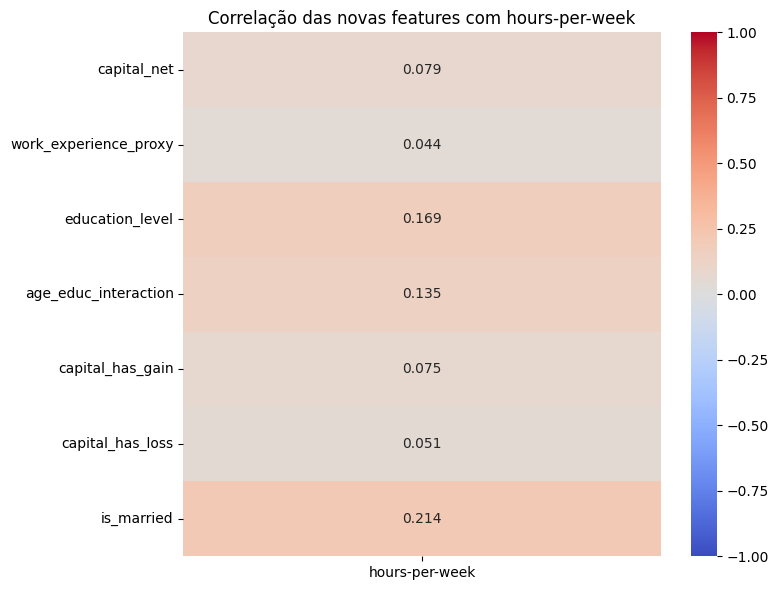

In [40]:
corr_cols = new_num_features + ['capital_has_gain', 'capital_has_loss', 'is_married', 'hours-per-week']
corr_matrix = df_fe[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix[['hours-per-week']].drop('hours-per-week'),
    annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Correlação das novas features com hours-per-week')
plt.tight_layout()
plt.show()


### 2.4 Atualização de X, y e do split

Após adicionar as novas features ao `df_fe`, redefine-se `X` e `y` e refaz-se o split para que o modelo as utilize. Também atualizam-se `num_cols` e `cat_cols`.


In [41]:
X = df_fe.drop('hours-per-week', axis=1).copy()
y = df_fe['hours-per-week'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Atualiza as listas de colunas para o ColumnTransformer
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Features numéricas ({len(num_cols)}): {num_cols}")
print(f"\nFeatures categóricas ({len(cat_cols)}): {cat_cols}")

# Reconstrói o preprocessor com as colunas atualizadas (incluindo novas features)
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformer, num_cols),
        ('categorical', categorical_transformer, cat_cols)
    ]
)
preprocessor


Features numéricas (12): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'capital_net', 'work_experience_proxy', 'education_level', 'is_married', 'age_educ_interaction', 'capital_has_gain', 'capital_has_loss']

Features categóricas (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 3. Modelagem

Treinar 3 modelos distintos usando `Pipeline` com o pré-processamento definido anteriormente e validação cruzada `RepeatedKFold` (5×):

- **Baseline**: Ridge / Lasso / Linear Regression
- **Ensemble 1**: Random Forest Regressor
- **Ensemble 2**: XGBoost Regressor

In [42]:
#incluir no pipe as novas features e treinar!!
#Linear Regression
linear_regression = LinearRegression()
linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', linear_regression)
])

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_scores = cross_val_score(
    linear_pipeline, X_train, y_train, 
    cv=rkf, 
    scoring='neg_root_mean_squared_error'
)
print(f"RMSE Médio (CV): {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

RMSE Médio (CV): 11.1377 (+/- 0.1921)


In [43]:
# Treinamento
linear_pipeline.fit(X_train, y_train)

# Predição no conjunto de teste
y_pred = linear_pipeline.predict(X_test)

# Cálculo das métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Métricas no Teste:\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}")

Métricas no Teste:
RMSE: 11.0715
MAE: 7.6512
R²: 0.2005


In [44]:
#Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

In [45]:
# Executando a validação cruzada para calcular o RMSE
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_results_rf = cross_val_score(
    rf_pipeline, X_train, y_train, 
    cv=rkf, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print(f"Random Forest - RMSE Médio (CV): {-cv_results_rf.mean():.4f} (+/- {cv_results_rf.std():.4f})")


# Treinar o pipeline
rf_pipeline.fit(X_train, y_train)

# Fazer predições
y_pred_rf = rf_pipeline.predict(X_test)

# Calcular métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Métricas Random Forest no Teste:\nRMSE: {rmse_rf:.4f}\nMAE: {mae_rf:.4f}\nR²: {r2_rf:.4f}")


Random Forest - RMSE Médio (CV): 10.9123 (+/- 0.1992)
Métricas Random Forest no Teste:
RMSE: 10.8396
MAE: 7.3823
R²: 0.2336


In [46]:
# Extrair nomes das colunas após as transformações
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extrair as importâncias do modelo treinado
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Criar um DataFrame para facilitar a visualização
df_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Mostrar as 10 mais importantes
print("Top 10 Features mais importantes (Random Forest):")
print(df_importances.head(10))

Top 10 Features mais importantes (Random Forest):
                                     feature  importance
0                             numerical__age    0.595125
70                   categorical__sex_Female    0.087492
71                     categorical__sex_Male    0.056028
6           numerical__work_experience_proxy    0.039532
113                categorical__income_<=50K    0.036422
114                 categorical__income_>50K    0.033575
49   categorical__occupation_Farming-fishing    0.029378
62       categorical__relationship_Own-child    0.016669
2                   numerical__education-num    0.015042
48   categorical__occupation_Exec-managerial    0.013911


In [47]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

# Cria o pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

In [48]:
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Executando a validação cruzada para RMSE
cv_results_xgb = cross_val_score(
    xgb_pipeline, X_train, y_train, 
    cv=rkf, 
    scoring='neg_root_mean_squared_error'
)

print(f"XGBoost - RMSE Médio (CV): {-cv_results_xgb.mean():.4f} (+/- {cv_results_xgb.std():.4f})")




# Treinar o pipeline completo
xgb_pipeline.fit(X_train, y_train)

# Fazer predições
y_pred_xgb = xgb_pipeline.predict(X_test)

# Calcular métricas finais
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Métricas XGBoost no Teste:\nRMSE: {rmse_xgb:.4f}\nMAE: {mae_xgb:.4f}\nR²: {r2_xgb:.4f}")

XGBoost - RMSE Médio (CV): 10.5684 (+/- 0.1862)
Métricas XGBoost no Teste:
RMSE: 10.4837
MAE: 7.1237
R²: 0.2831


## 4. Otimização e Seleção de Modelo

Realizamos hyperparameter tuning com `GridSearchCV` nos modelos mais promissores, comparando os resultados para escolher o melhor modelo.

In [49]:
# blablabal

# Parâmetros para Linear Regression
param_grid_lr = {
    'regressor__fit_intercept': [True, False]
}

# Parâmetros para Random Forest
param_grid_rf = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

# Parâmetros para XGBoost
param_grid_xgb = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__max_depth': [3, 6]
}

In [50]:
# --- GRID SEARCH: LINEAR REGRESSION ---
grid_lr = GridSearchCV(linear_pipeline, param_grid_lr, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'regressor__fit_intercept': [True, False]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [51]:
# --- GRID SEARCH: RANDOM FOREST ---
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [10, 20, ...], 'regressor__min_samples_split': [2, 5], 'regressor__n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [52]:
# --- GRID SEARCH: XGBOOST ---
grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'regressor__learning_rate': [0.01, 0.1], 'regressor__max_depth': [3, 6], 'regressor__n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [53]:
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Melhor RMSE (CV)': [
        -grid_lr.best_score_, 
        -grid_rf.best_score_, 
        -grid_xgb.best_score_
    ],
    'Melhores Parâmetros': [
        grid_lr.best_params_, 
        grid_rf.best_params_, 
        grid_xgb.best_params_
    ]
})

print(results.sort_values(by='Melhor RMSE (CV)'))

              Modelo  Melhor RMSE (CV)  \
2            XGBoost         10.569114   
1      Random Forest         10.678731   
0  Linear Regression         11.138295   

                                 Melhores Parâmetros  
2  {'regressor__learning_rate': 0.1, 'regressor__...  
1  {'regressor__max_depth': 10, 'regressor__min_s...  
0                 {'regressor__fit_intercept': True}  


## 5. Análise de Métricas

Avaliamos o desempenho dos modelos com as métricas: RMSE, MAE e R². Comparamos os resultados entre todos os modelos treinados.

Comparando os três modelos treinados, o XGBoost apresentou o melhor desempenho, com o menor RMSE (10.4837) e menor MAE (7.1237), indicando que suas previsões tiveram, em média, erros menores do que os demais modelos. Além disso, também apresentou o maior R² (0.2831), explicando uma proporção maior da variabilidade da variável alvo.

O Random Forest teve desempenho intermediário, com RMSE de 10.8396, MAE de 7.3823 e R² de 0.2336. Ele melhorou em relação a Regressão Linear, mas ainda ficou abaixo do XGBoost.

A Regressão Linear foi o modelo com pior desempenho entre os três, apresentando o maior RMSE (11.0715), maior MAE (7.6512) e menor R² (0.2005). Isso sugere que a relação entre as variáveis explicativas e a variável alvo provavelmente não é totalmente linear, favorecendo modelos mais flexíveis, como Random Forest e XGBoost.

Portanto, considerando simultaneamente RMSE, MAE e R², o XGBoost foi o melhor modelo entre os avaliados.


## 6. Interpretação e Explicabilidade

Analisamos quais features mais impactam as previsões do melhor modelo, usando importância de features (feature importances do Random Forest / XGBoost) e análise de resíduos.

C:\Users\lujiq\AppData\Local\Temp\ipykernel_15336\3662792856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')


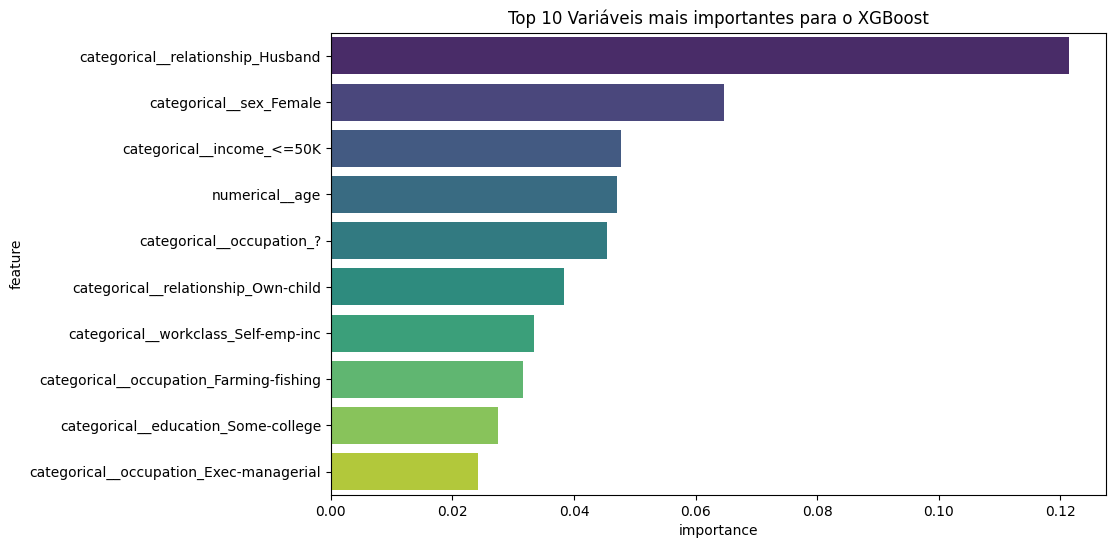

In [61]:
# Extrair importâncias do modelo XGBoost treinado
importances = xgb_pipeline.named_steps['regressor'].feature_importances_
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Criar DataFrame para visualização
df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_imp = df_imp.sort_values(by='importance', ascending=False).head(10)

# Plotar
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')
plt.title('Top 10 Variáveis mais importantes para o XGBoost')
plt.show()

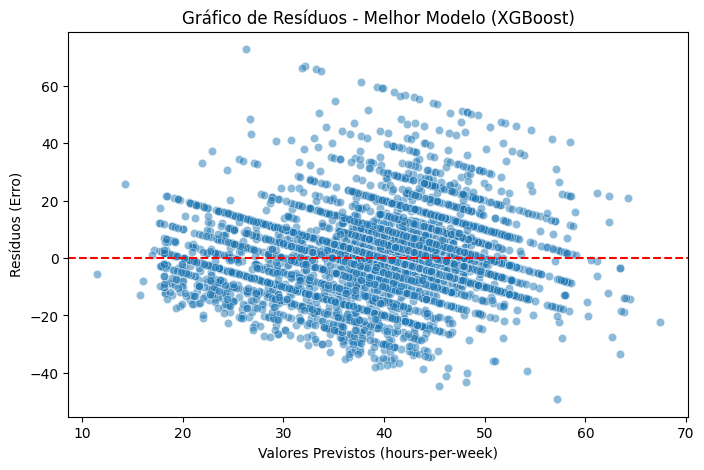

In [55]:
# Calcular resíduos (Erro = Real - Previsto)
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_xgb, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Previstos (hours-per-week)')
plt.ylabel('Resíduos (Erro)')
plt.title('Gráfico de Resíduos - Melhor Modelo (XGBoost)')
plt.show()

## 7. Discussão Crítica e Conclusões

Discutir as limitações do modelo treinado, como multimodalidade da variável alvo, heterocedasticidade e questões de causalidade vs. correlação.